In [1]:
import pandas as pd
import numpy as np

# loading datasets
ratings = pd.read_csv("../data/ml-latest/ratings.csv")
movies = pd.read_csv("../data/ml-latest/movies.csv")

ratings.shape,movies.shape

((33832162, 4), (86537, 3))

In [26]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [27]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

print(f"Number of users: {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Number of ratings: {n_ratings}")

Number of users: 330975
Number of movies: 83239
Number of ratings: 33832162


* Sparsity is a condition where most values in a dataset are zero, and it is used to save memory, speed up computation, and improve machine learning efficiency.

In [13]:
sparsity = 1 - (n_ratings/(n_users * n_movies))
print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9988


In [22]:
ratings.groupby("movieId")["userId"].count().sort_values(ascending=False).head()

movieId
318     122296
356     113581
296     108756
2571    107056
593     101802
Name: userId, dtype: int64

In [25]:
ratings.groupby("userId")['movieId'].nunique().head()

userId
1    62
2    91
3    30
4    30
5    43
Name: movieId, dtype: int64

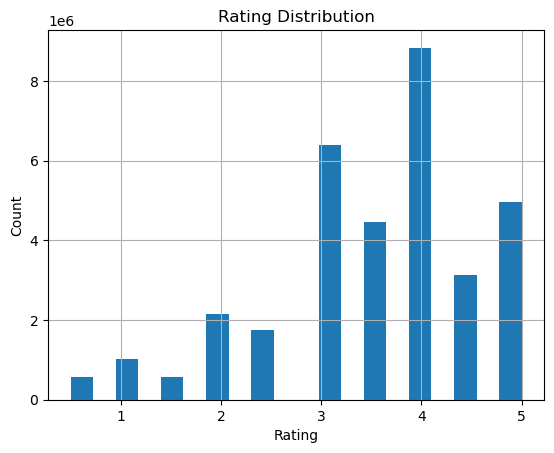

In [34]:
import matplotlib.pyplot as plt

ratings['rating'].hist(bins=20)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [38]:
user_activity = ratings.groupby('userId').size()
print(user_activity.describe()),user_activity.sort_values(ascending=False)

count    330975.00000
mean        102.21969
std         232.15453
min           1.00000
25%          15.00000
50%          31.00000
75%          98.00000
max       33332.00000
dtype: float64


(None,
 userId
 189614    33332
 48766      9554
 207216     9178
 175998     9016
 76618      8919
           ...  
 118297        1
 228609        1
 159558        1
 12701         1
 104595        1
 Length: 330975, dtype: int64)

In [39]:
movie_popularity = ratings.groupby('movieId').size()
print(movie_popularity.describe())

count     83239.000000
mean        406.446041
std        2806.975876
min           1.000000
25%           2.000000
50%           5.000000
75%          26.000000
max      122296.000000
dtype: float64


In [41]:
movie_popularity.sort_values(ascending=False).head()

movieId
318     122296
356     113581
296     108756
2571    107056
593     101802
dtype: int64

In [42]:
data = pd.merge(ratings,movies, on = "movieId")
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,1225734739,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,110,4.0,1225865086,Braveheart (1995),Action|Drama|War
2,1,158,4.0,1225733503,Casper (1995),Adventure|Children
3,1,260,4.5,1225735204,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
4,1,356,5.0,1225735119,Forrest Gump (1994),Comedy|Drama|Romance|War


In [52]:
top_movies = data.groupby("title").size().sort_values(ascending=False).head(10)
top_movies

title
Shawshank Redemption, The (1994)                         122296
Forrest Gump (1994)                                      113581
Pulp Fiction (1994)                                      108756
Matrix, The (1999)                                       107056
Silence of the Lambs, The (1991)                         101802
Star Wars: Episode IV - A New Hope (1977)                 97202
Fight Club (1999)                                         86207
Schindler's List (1993)                                   84232
Jurassic Park (1993)                                      83026
Star Wars: Episode V - The Empire Strikes Back (1980)     80200
dtype: int64

In [53]:
data.to_csv("../data/processed_data.csv",index=False)

In [58]:
data["timestamp"] = pd.to_datetime(data['timestamp'],unit='s')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,2008-11-03 17:52:19,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,110,4.0,2008-11-05 06:04:46,Braveheart (1995),Action|Drama|War
2,1,158,4.0,2008-11-03 17:31:43,Casper (1995),Adventure|Children
3,1,260,4.5,2008-11-03 18:00:04,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
4,1,356,5.0,2008-11-03 17:58:39,Forrest Gump (1994),Comedy|Drama|Romance|War


In [59]:
data["year"] = data["timestamp"].dt.year
data["month"] = data["timestamp"].dt.month
data["day"] = data["timestamp"].dt.day
data.head()

,userId,movieId,rating,timestamp,title,genres,year,month,day
0,1,1,4.0,2008-11-03 17:52:19,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,2008,11,3
1,1,110,4.0,2008-11-05 06:04:46,Braveheart (1995),Action|Drama|War,2008,11,5
2,1,158,4.0,2008-11-03 17:31:43,Casper (1995),Adventure|Children,2008,11,3
3,1,260,4.5,2008-11-03 18:00:04,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,2008,11,3
4,1,356,5.0,2008-11-03 17:58:39,Forrest Gump (1994),Comedy|Drama|Romance|War,2008,11,3


In [60]:
print("Earliest:",data["timestamp"].min())
print("Latest:",data["timestamp"].max())

Earliest: 1995-01-09 11:46:44
Latest: 2023-07-20 08:53:33


In [61]:
data = data.sort_values("timestamp")

In [62]:
data.head()

,userId,movieId,rating,timestamp,title,genres,year,month,day
15254009,149954,1176,4.0,1995-01-09 11:46:44,"Double Life of Veronique, The (Double Vie de V...",Drama|Fantasy|Romance,1995,1,9
9617113,94532,21,3.0,1995-01-09 11:46:49,Get Shorty (1995),Comedy|Crime|Thriller,1995,1,9
9617119,94532,47,5.0,1995-01-09 11:46:49,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1995,1,9
9617162,94532,1079,3.0,1995-01-09 11:46:49,"Fish Called Wanda, A (1988)",Comedy|Crime,1995,1,9
16958935,166476,50,5.0,1996-01-29 00:00:00,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1996,1,29


In [63]:
data.reset_index(drop=True,inplace=True)

In [64]:
data.head()

,userId,movieId,rating,timestamp,title,genres,year,month,day
0,149954,1176,4.0,1995-01-09 11:46:44,"Double Life of Veronique, The (Double Vie de V...",Drama|Fantasy|Romance,1995,1,9
1,94532,21,3.0,1995-01-09 11:46:49,Get Shorty (1995),Comedy|Crime|Thriller,1995,1,9
2,94532,47,5.0,1995-01-09 11:46:49,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1995,1,9
3,94532,1079,3.0,1995-01-09 11:46:49,"Fish Called Wanda, A (1988)",Comedy|Crime,1995,1,9
4,166476,50,5.0,1996-01-29 00:00:00,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1996,1,29


In [65]:
split_index = int(len(data) * 0.8)

In [66]:
train = data.iloc[:split_index]
test = data.iloc[split_index:]

In [67]:
print("Train size:",len(train))
print("Test size:",len(test))

Train size: 27065729
Test size: 6766433


In [68]:
print("Train last date:",train["timestamp"].max())
print("Test first date:",test["timestamp"].min())

Train last date: 2018-07-08 23:58:35
Test first date: 2018-07-08 23:58:49


In [69]:
train.to_csv("../data/train.csv",index=False)
test.to_csv("../data/test.csv",index=False)

In [70]:
train.shape,test.shape

((27065729, 9), (6766433, 9))